In [45]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')  # 
plt.rc('axes', unicode_minus=False)

In [47]:
df = pd.read_csv('data/일별평균대기오염도_2022(에어코리아).csv', encoding='cp949')
df.head()


,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,강남구,0.029,0.014,0.5,0.003,25.0,12.0
1,20220101,홍릉로,0.038,0.009,0.6,0.004,27.0,16.0
2,20220101,행주,0.034,0.012,0.7,0.004,27.0,16.0
3,20220101,항동,0.030,0.011,0.5,0.003,27.0,14.0
4,20220101,한강대로,0.037,0.011,0.6,0.003,34.0,14.0


In [48]:
# df['측정일시'] : 20220101 => "2022-01-01" => datetime형으로 형변환(df['측정일'])
df['측정일'] = df['측정일시'].astype(str)
df.head()

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥),측정일
0,20220101,강남구,0.029,0.014,0.5,0.003,25.0,12.0,20220101
1,20220101,홍릉로,0.038,0.009,0.6,0.004,27.0,16.0,20220101
2,20220101,행주,0.034,0.012,0.7,0.004,27.0,16.0,20220101
3,20220101,항동,0.030,0.011,0.5,0.003,27.0,14.0,20220101
4,20220101,한강대로,0.037,0.011,0.6,0.003,34.0,14.0,20220101


In [51]:
df['측정일'] = df['측정일'].str[:4] + "-" + df['측정일'].str[4:6] + "-" + df['측정일'].str[6:]

In [52]:
df['측정일'] = pd.to_datetime(df['측정일'])

In [53]:
df.head(1)

,측정일시,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥),측정일
0,20220101,강남구,0.029,0.014,0.5,0.003,25.0,12.0,2022-01-01


In [54]:
cols = df.columns.tolist()
cols.remove('측정일')
cols

['측정일시',
 '측정소명',
 '이산화질소농도(ppm)',
 '오존농도(ppm)',
 '일산화탄소농도(ppm)',
 '아황산가스농도(ppm)',
 '미세먼지농도(㎍/㎥)',
 '초미세먼지농도(㎍/㎥)']

In [55]:
new_cols = [cols[0], '측정일'] + cols[1:]
df = df[new_cols]
df.head(1)

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
0,20220101,2022-01-01,강남구,0.029,0.014,0.5,0.003,25.0,12.0


In [56]:
# 서울시 측정소명들
print('측정소명 갯수 :', df['측정소명'].unique().shape)
df['측정소명'].unique()

측정소명 갯수 : (50,)


array(['강남구', '홍릉로', '행주', '항동', '한강대로', '청계천로', '천호대로', '중랑구', '중구',
       '종로구', '종로', '정릉로', '자연사박물관', '은평구', '용산구', '올림픽공원', '영등포로',
       '영등포구', '양천구', '신촌로', '시흥대로', '송파구', '세곡', '성북구', '성동구', '화랑로',
       '서초구', '서울숲', '서대문구', '북한산', '마포아트센터', '마포구', '동작대로', '동작구',
       '동대문구', '도산대로', '도봉구', '노원구', '남산', '금천구', '구로구', '광진구', '관악산',
       '관악구', '공항대로', '강서구', '강북구', '강변북로', '강동구', '강남대로'], dtype=object)

In [57]:
loc_name = '공항대로'
df_flt = df[df['측정소명']==loc_name]
df_flt.head()

,측정일시,측정일,측정소명,이산화질소농도(ppm),오존농도(ppm),일산화탄소농도(ppm),아황산가스농도(ppm),미세먼지농도(㎍/㎥),초미세먼지농도(㎍/㎥)
44,20220101,2022-01-01,공항대로,0.035,0.010,0.6,0.002,31.0,15.0
93,20220102,2022-01-02,공항대로,0.027,0.017,0.5,0.003,37.0,22.0
143,20220103,2022-01-03,공항대로,0.041,0.007,0.6,0.003,31.0,18.0
196,20220104,2022-01-04,공항대로,0.032,0.010,0.5,0.003,48.0,21.0
244,20220105,2022-01-05,공항대로,0.045,0.004,0.8,0.003,56.0,34.0


In [58]:
print(len(df_flt))
print(df_flt.info())

365
<class 'pandas.core.frame.DataFrame'>
Int64Index: 365 entries, 44 to 18249
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   측정일시          365 non-null    int64         
 1   측정일           365 non-null    datetime64[ns]
 2   측정소명          365 non-null    object        
 3   이산화질소농도(ppm)  365 non-null    float64       
 4   오존농도(ppm)     365 non-null    float64       
 5   일산화탄소농도(ppm)  365 non-null    float64       
 6   아황산가스농도(ppm)  365 non-null    float64       
 7   미세먼지농도(㎍/㎥)   365 non-null    float64       
 8   초미세먼지농도(㎍/㎥)  365 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 28.5+ KB
None


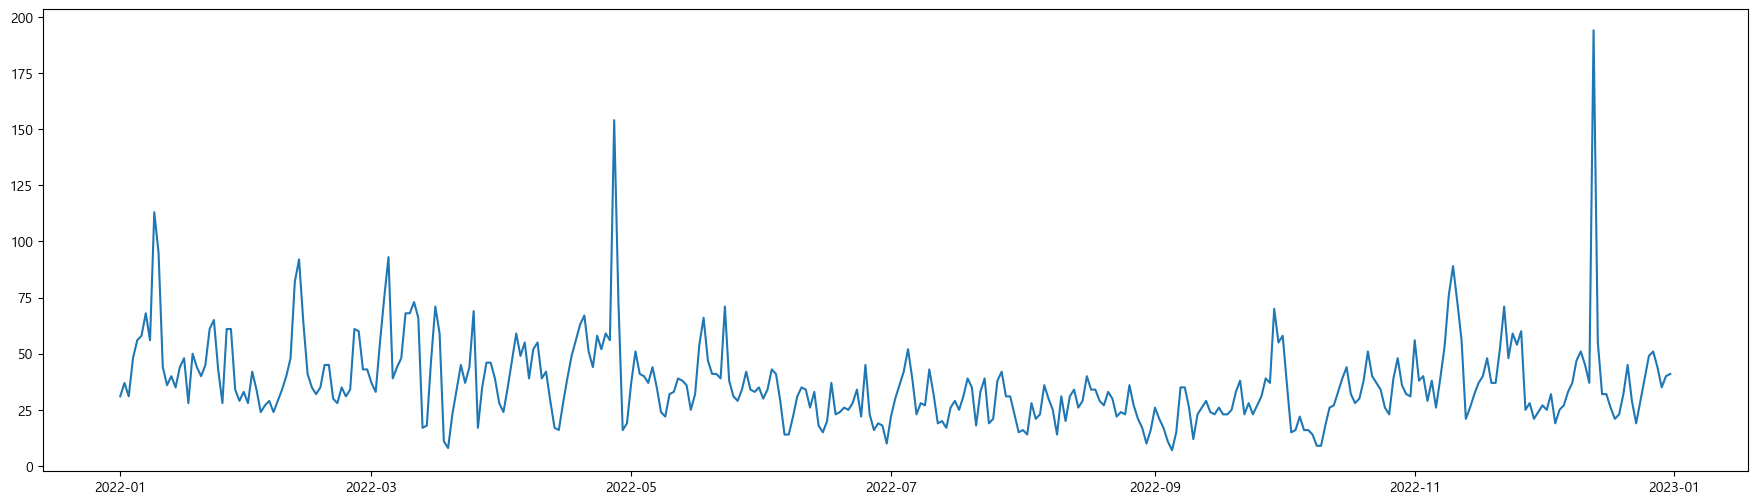

In [59]:
plt.figure(figsize=(22,6))
plt.plot(df_flt['측정일'],df_flt['미세먼지농도(㎍/㎥)'])

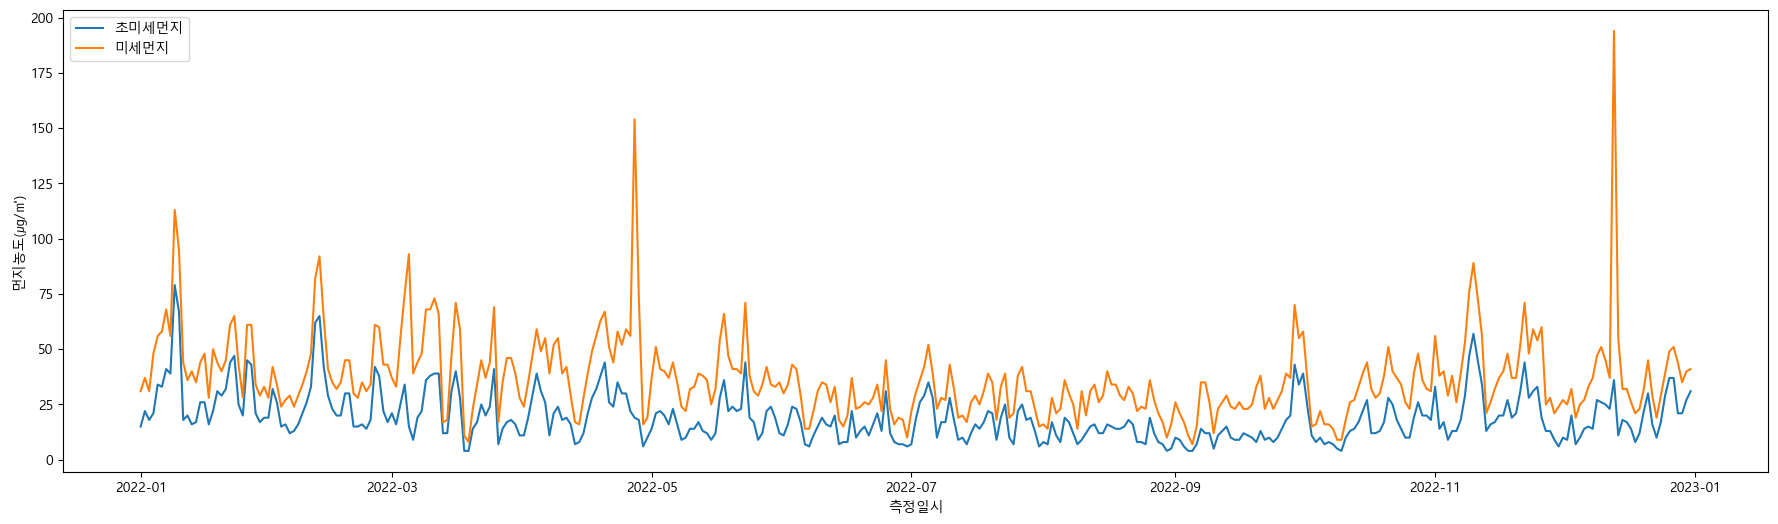

In [60]:
plt.figure(figsize=(22,6))
plt.plot(df_flt['측정일'], df_flt['초미세먼지농도(㎍/㎥)'], label='초미세먼지' )
plt.plot(df_flt['측정일'],df_flt['미세먼지농도(㎍/㎥)'], label='미세먼지')
plt.xlabel('측정일시')
plt.ylabel('먼지농도(㎍/㎥)')
plt.legend(loc='upper left')
plt.show()

In [61]:
df_flt2 = df_flt[['측정일','미세먼지농도(㎍/㎥)']]
ts = df_flt2.set_index('측정일')
ts.head()

,미세먼지농도(㎍/㎥)
측정일,
2022-01-01,31.0
2022-01-02,37.0
2022-01-03,31.0
2022-01-04,48.0
2022-01-05,56.0


In [62]:
df_flt2


,측정일,미세먼지농도(㎍/㎥)
44,2022-01-01,31.0
93,2022-01-02,37.0
143,2022-01-03,31.0
196,2022-01-04,48.0
244,2022-01-05,56.0
...,...,...
18043,2022-12-27,51.0
18095,2022-12-28,44.0
18143,2022-12-29,35.0
18193,2022-12-30,40.0


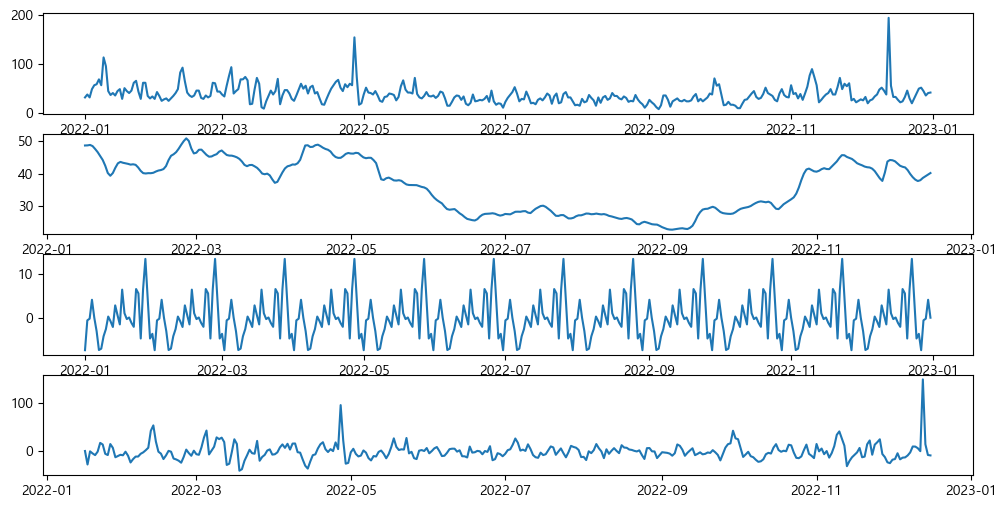

In [63]:
# 시계열 데이터의 구조를 분해해 주는 도구
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(ts['미세먼지농도(㎍/㎥)'],
                           model='additive',
                           period=30)

fig, axes = plt.subplots(4,1,figsize=(12,6))
axes[0].plot(result.observed)
axes[1].plot(result.trend)
axes[2].plot(result.seasonal)
axes[3].plot(result.resid)
plt.show()

In [64]:
def plot_seasonal_decompose(result):
    fig, axes = plt.subplots(4,1, figsize=(12,6))
    result.observed.plot(ax=axes[0])
    axes[0].set_ylabel('관측값')
    axes[1].plot(result.trend)
    axes[1].set_ylabel('트렌드')
    axes[2].plot(result.seasonal)
    axes[2].set_ylabel('계절성')
    axes[3].plot(result.resid)
    axes[3].set_ylabel('잔차')
    plt.xlabel('날짜')
    plt.tight_layout()
    plt.show()

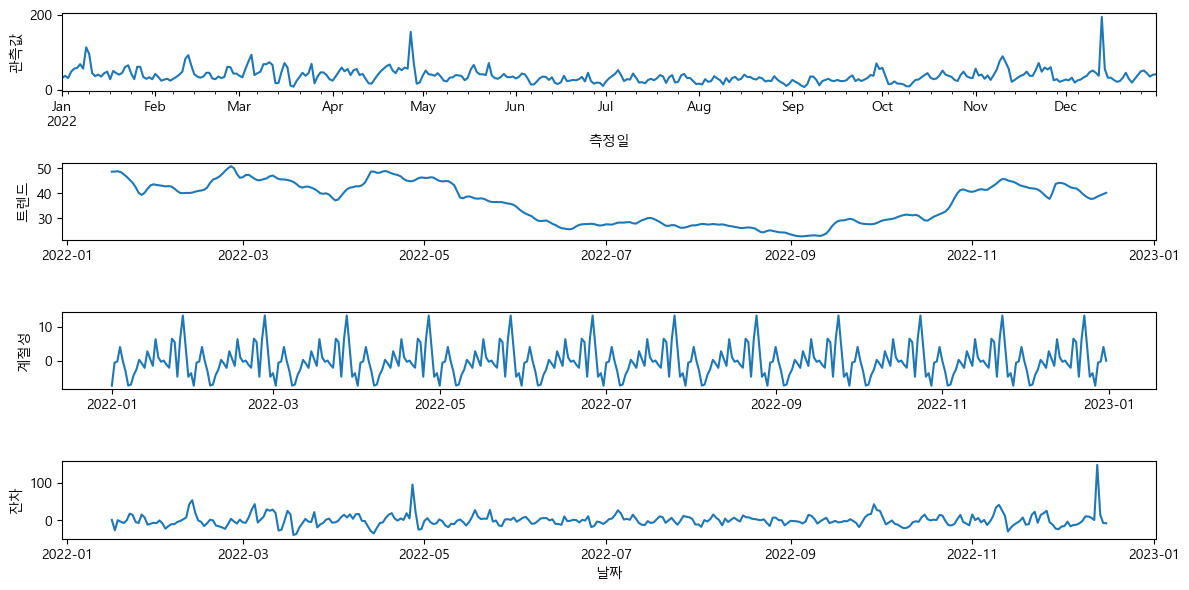

In [65]:
plot_seasonal_decompose(result)

## seasonal_decompose & RNN/LSTM/GRU & Prohet
                 -  분석 -                 - 예측 -

In [66]:
df_flt2.columns = ['ds','y'] #  prophet의 fit시 컬럼명을 ds, y
df_flt2

,ds,y
44,2022-01-01,31.0
93,2022-01-02,37.0
143,2022-01-03,31.0
196,2022-01-04,48.0
244,2022-01-05,56.0
...,...,...
18043,2022-12-27,51.0
18095,2022-12-28,44.0
18143,2022-12-29,35.0
18193,2022-12-30,40.0


In [69]:
%pip install prophet


   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/13.3 MB 9.1 MB/s eta 0:00:02
   ------------ --------------------------- 4.2/13.3 MB 10.5 MB/s eta 0:00:01
   ------------------- -------------------- 6.6/13.3 MB 10.6 MB/s eta 0:00:01
   ------------------------- -------------- 8.4/13.3 MB 10.6 MB/s eta 0:00:01
   -------------------------------- ------- 10.7/13.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------  13.1/13.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 13.3/13.3 MB 10.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 12.5 MB/s eta 0:00:00

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [70]:
from prophet  import Prophet
p_model = Prophet()
p_model.fit(df_flt2)

Importing plotly failed. Interactive plots will not work.
17:55:29 - cmdstanpy - INFO - Chain [1] start processing
17:55:29 - cmdstanpy - INFO - Chain [1] done processing


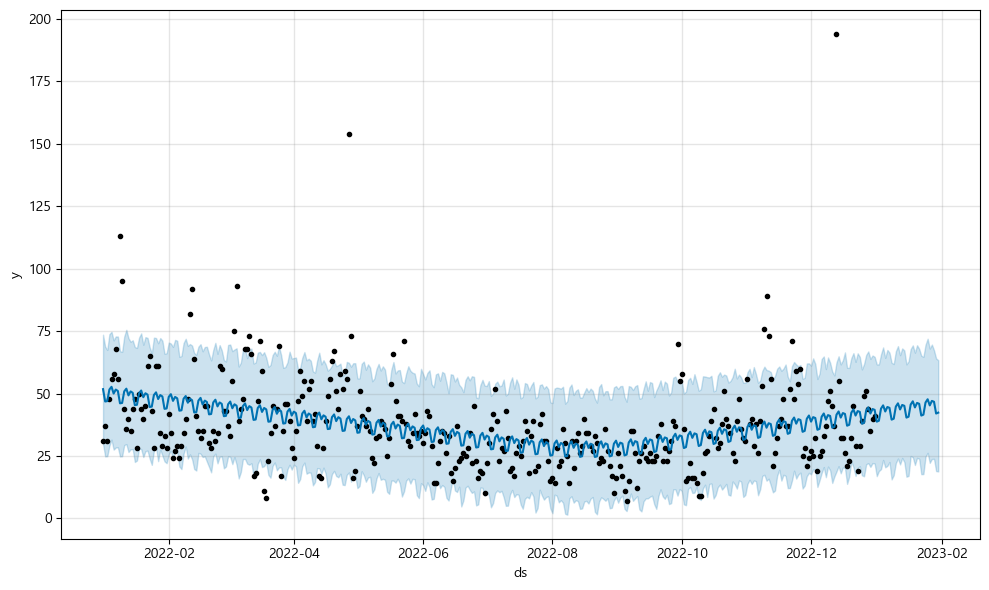

In [71]:
# p_model을 이용하여 30일 이후의 데이터를 예측
future = p_model.make_future_dataframe(periods=30)
forecast = p_model.predict(future)
f = p_model.plot(forecast)

In [72]:
forecast[['ds','yhat', 'yhat_lower', 'yhat_upper']].tail(30)

,ds,yhat,yhat_lower,yhat_upper
365,2023-01-01,38.738106,16.908479,61.695077
366,2023-01-02,39.108625,18.956848,61.671489
367,2023-01-03,43.966852,19.699870,65.697755
368,2023-01-04,45.272123,23.392360,68.481560
369,2023-01-05,42.812810,20.444851,64.305617
370,2023-01-06,44.613248,21.025973,67.467563
371,2023-01-07,44.275744,22.563226,66.387446
372,2023-01-08,39.550766,15.603053,62.360585
373,2023-01-09,39.921285,17.275468,61.821098
374,2023-01-10,44.779513,22.126592,66.942109
